## 0. Import libraries

In [ ]:
import os 
os.chdir('../..')

import numpy as np
import pandas as pd
import seaborn as sns
import tellurium as te
import re
import textwrap
import matplotlib.pyplot as plt
import itertools
import pickle

from mpl_toolkits.axes_grid1 import make_axes_locatable

from roadrunner import Config, Logger
Logger.disableLogging()
Config.setValue(Config.ROADRUNNER_DISABLE_PYTHON_DYNAMIC_PROPERTIES, True)
Config.setValue(Config.LOADSBMLOPTIONS_RECOMPILE, False) 
Config.setValue(Config.LLJIT_OPTIMIZATION_LEVEL, 4)
Config.setValue(Config.LLVM_SYMBOL_CACHE, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_GVN, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_CFG_SIMPLIFICATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_COMBINING, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_INST_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_DEAD_CODE_ELIMINATION, True)
Config.setValue(Config.LOADSBMLOPTIONS_OPTIMIZE_INSTRUCTION_SIMPLIFIER, True)
Config.setValue(Config.SIMULATEOPTIONS_COPY_RESULT, True)

In [ ]:
rfit = te.loada(r'iMC057.txt')

model_rxns = pd.read_csv(r'Reactions.csv')

In [ ]:
with open(r'filtering_parameter_sets\final_params.pkl', 'rb') as file:
    trainparams = pickle.load(file)

In [ ]:
param_labels_dict = {}
param_values_dict = {}
for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
    if pid in trainparams[60][2]:
        param_values_dict[pid] = trainparams[60][2][pid]
        param_labels_dict[pid] = k

In [ ]:
# Dilution factors we want to test
d_factors = [1/200, 1/100, 1/50, 1/10]
d_factors.reverse()

## Figure 4A:
### How does the amount of flux moving through reactions (grouped into biosynthetic modules) change over time and across dilution factors?

In [ ]:
pathway_dict = {
    'TCA Cycle': [
        'R1',   # 2-oxoglutarate dehydrogenase subunit E1
        'R7',   # Aconitate hydratase A
        'R8',   # Aconitate hydratase B
        'R20',  # Fumarate hydratase class I
        'R25',  # Malate dehydrogenase
        'R27',  # NADP-dependent isocitrate dehydrogenase
        'R28',  # NADP-dependent isocitrate dehydrogenase
        'R41',  # Succinate dehydrogenase
        'R42',  # Succinyl-CoA ligase
        'R46',  # Type II citrate synthase
        'R47'   # Isocitrate lyase
    ],

    'Glycolysis / Gluconeogenesis': [
        'R10',  # ATP-dependent 6-phosphofructokinase
        'R13',  # Enolase
        'R18',  # Fructose 1,6-bisphosphatase
        'R19',  # Fructose-bisphosphate aldolase
        'R21',  # Glucose-6-phosphate isomerase
        'R22',  # Glyceraldehyde-3-phosphate dehydrogenase
        'R23',  # Glycogen phosphorylase
        'R30',  # Phosphoenolpyruvate carboxykinase (ATP)
        'R32',  # Phosphoenolpyruvate synthase
        'R33',  # Phosphoglucomutase
        'R34',  # Phosphoglycerate kinase
        'R35',  # Phosphoglycerate mutase
        'R37',  # Pyruvate kinase I
        'R38',  # Pyruvate kinase II
        'R45'   # Triose-phosphate isomerase
    ],

    'Pentose Phosphate Pathway': [
        'R39',  # Ribose-5-phosphate isomerase
        'R40',  # Ribulose-phosphate 3-epimerase
        'R43',  # Transaldolase
        'R44',   # Transketolase
        'R54',  # Glucose-6-phosphate dehydrogenase
    ],

    'Fatty Acid Biosynthesis': [
        'R2',   # 3-oxoacyl-ACP reductase
        'R3',   # 3-oxoacyl-ACP synthase I
        'R4',   # 3-oxoacyl-ACP synthase III
        'R6',   # Acetyl-CoA carboxytransferase
        'R11',  # Beta-hydroxydecanoyl-ACP dehydratase
        'R12',  # Beta-ketoacyl-[acyl-carrier-protein] synthase II
        'R14',  # Enoyl-[acyl-carrier-protein] reductase
        'R24'   # Long-chain-fatty-acid--CoA ligase
        'R26'   # Malonyl CoA-ACP transacylase
    ],

    'Fatty Acid Degradation (β-Oxidation)': [
        'R5',   # Acetyl-CoA C-acyltransferase
        'R15',  # Fatty acid oxidation complex subunit alpha
        'R16',  # Fatty acid oxidation complex subunit alpha
        'R17'  # Fatty acid oxidation complex subunit alpha
        
    ],

    'Pyruvate Metabolism': [
        'R31',  # Phosphoenolpyruvate carboxylase
        'R36',  # Pyruvate dehydrogenase E1 component
        'R48',  # Acetyl-CoA synthetase
        'R50',  # Acetate kinase
        'R53'   # Lactate dehydrogenase
    ],

    'Glycine & Serine Metabolism': [
        'R49',  # Serine hydroxymethyltransferase
        'R52'  # L-serine ammonia-lyase
    ],

    'Energy & Nucleotide Metabolism + CO2/Bicarb Conversion': [
        'R9',   # Adenylate kinase
        'R29',  # Nucleoside-diphosphate kinase
        'R51' # Carbonic anhydrase
        
    ]
}

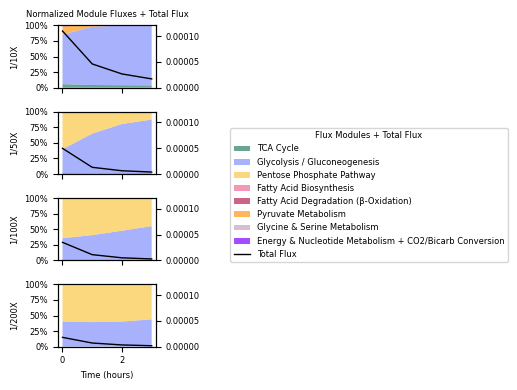

In [ ]:
time_points = np.arange(0, 4*60*60+1, 60*60)  # 30 min intervals for 4 hours

fig, axes = plt.subplots(len(d_factors), 1, figsize=(2.2, 4), sharex=True)

def format_dilution_label(d):
    if d == 0.1:
        return "1/10X"
    elif d == 0.02:
        return "1/50X"
    elif d == 0.01:
        return "1/100X"
    elif d == 0.005:
        return "1/200X"

all_total_fluxes = []  # For global y-axis scaling
line_axes = []         # Store second y-axes

for i, d in enumerate(d_factors):
    ax = axes[i]

    module_fluxes = {module: [] for module in pathway_dict}
    total_flux_over_time = []

    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 49, 51, 53],
        [*param_values_dict.values(), d, 0, 0, 0]
    )
    rfit.reset()

    for j in range(len(time_points)-1):
        rfit.simulate(int(time_points[j]), int(time_points[j+1]))
        reaction_fluxes = np.abs(rfit.getReactionRates())
        reaction_ids = rfit.getReactionIds()

        total_flux = np.sum(reaction_fluxes)
        total_flux_over_time.append(total_flux)

        module_fluxes_step = {}
        for module, labels in pathway_dict.items():
            module_size = len(labels) if len(labels) > 0 else 1
            module_flux = sum(reaction_fluxes[reaction_ids.index(label)]
                            for label in labels if label in reaction_ids)
            module_fluxes_step[module] = module_flux / module_size

        total_at_t = sum(module_fluxes_step.values()) if total_flux > 0 else 1
        for module in module_fluxes_step:
            module_fluxes[module].append(module_fluxes_step[module] / total_at_t)

    all_total_fluxes.extend(total_flux_over_time)
    stacked_fluxes = np.vstack([module_fluxes[module] for module in module_fluxes])

    module_color_dict = {
        "TCA Cycle": "#2A7F62",
        "Glycolysis / Gluconeogenesis": "#8390FA",
        "Pentose Phosphate Pathway": "#FAC748",
        "Fatty Acid Biosynthesis": "#F06C9B",
        "Fatty Acid Degradation (β-Oxidation)": "#B6244F",
        "Pyruvate Metabolism": "#FF9913",
        "Glycine & Serine Metabolism": "#C8A2C8",
        "Energy & Nucleotide Metabolism + CO2/Bicarb Conversion": "#7F00FF",
    }
    colors = [module_color_dict[m] for m in module_fluxes]

    if stacked_fluxes.shape[1] == len(time_points) - 1:
        ax.stackplot(time_points[:-1] / 3600, stacked_fluxes,
                     labels=module_fluxes.keys(), colors=colors, alpha=0.7)
    else:
        print(f"Shape mismatch for d={d}: {stacked_fluxes.shape} vs {len(time_points)-1}")

    ax.set_ylabel(format_dilution_label(d), fontsize=6)

    # Set left y-axis as percentage
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=6)
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

    # Twin axis for total flux line
    ax2 = ax.twinx()
    line_total_flux, = ax2.plot(time_points[:-1] / 3600, total_flux_over_time, color='black', lw=1, label="Total Flux")
    line_axes.append(ax2)
    ax2.tick_params(axis='y', labelsize=6)

    if i == 0:
        ax.set_title("Normalized Module Fluxes + Total Flux", fontsize=6)

    if i == len(d_factors) - 1:
        ax.set_xlabel("Time (hours)", fontsize=6)
        ax2.set_xlabel("Time (hours)", fontsize=6)

    rfit.resetToOrigin()

# Set consistent total flux y-limits
max_total_flux = max(all_total_fluxes)
for ax2 in line_axes:
    ax2.set_ylim(0, max_total_flux * 1.1)

# Shared legend outside plot
handles_area, labels_area = axes[0].get_legend_handles_labels()
handles = handles_area + [line_total_flux]
labels = labels_area + ["Total Flux"]
fig.legend(handles, labels, title="Flux Modules + Total Flux",
           bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=6, title_fontsize=6)

plt.tight_layout()
plt.savefig("Figures/Figure_4A.svg")
plt.show()

## Figure 4B:
### Zoom in to each of these biosynthetic modules (1 subplot each). What does the total reaction flux (y axis) look like across dilution factors (x axis)? What is the dilution factor which achieves half-max (vertical line)?

In [ ]:
d_factors = [1/200, 1/100, 1/50, 1/30, 1/20, 1/15, 1/10]

In [ ]:
def simulate_and_record_rates(rfit, d):
    print(d)
    totaltime = 60
    addedtime = 60*5
    
    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 49, 51, 53],
        [*param_values_dict.values(), d, 0, 0, 0]
    )
    rfit.reset()

    rfit.simulate(0, totaltime)
    ratesarray = np.atleast_2d(rfit.getReactionRates()).T  # Make it a column vector (n_reactions, 1)

    while totaltime <= 4*60*60:
        rfit.model.setGlobalParameterValues(
            [*param_labels_dict.values(), 2, 49, 51, 53],
            [*param_values_dict.values(), d, 0, 0, 0]
        )
        rfit.reset()
        rfit.simulate(0, totaltime + addedtime)
        rates = np.atleast_2d(rfit.getReactionRates()).T  # Convert to column vector

        ratesarray = np.concatenate((ratesarray, rates), axis=1)  # Append as new column
        totaltime += addedtime

        rfit.resetToOrigin()
    
    rfit.resetToOrigin()

    return ratesarray

In [ ]:
def calc_reaction_metrics(ratesarray):
    addedtime = 300
    # Assume ratesarray has shape (n_reactions, n_timepoints)
    timepoints = np.arange(ratesarray.shape[1]) * addedtime  # Generate time values

    # 1) Find the time point at which the max magnitude rate occurs
    max_indices = np.argmax(np.abs(ratesarray), axis=1)  # Indices of max abs value
    max_times = timepoints[max_indices]  # Convert indices to time values

    # 2) Find the max magnitude rate value
    max_rates = np.max(np.abs(ratesarray), axis=1)

    # 3) Compute the average rate for each reaction
    average_rates = np.mean(ratesarray, axis=1)

    # 4) Compute the total magnitude of flux (integral of absolute rates over time)
    total_flux = np.sum(np.abs(ratesarray), axis=1) * addedtime  # Trapezoidal approx.

    return max_times, max_rates, average_rates, total_flux

In [ ]:
dil_max_times = []
dil_max_rates = []
dil_avg_rates = []
dil_tot_flux = []

# Simulate the endogenous lysate at each of the dilution factors
for dil_fact in d_factors:
    rates_array = simulate_and_record_rates(rfit, dil_fact)
    appenders = calc_reaction_metrics(rates_array)
    mylists = [dil_max_times, dil_max_rates, dil_avg_rates, dil_tot_flux]
    for x, lst in zip(appenders, mylists):
        lst.append(x)

0.005
0.01
0.02
0.03333333333333333
0.05
0.06666666666666667
0.1


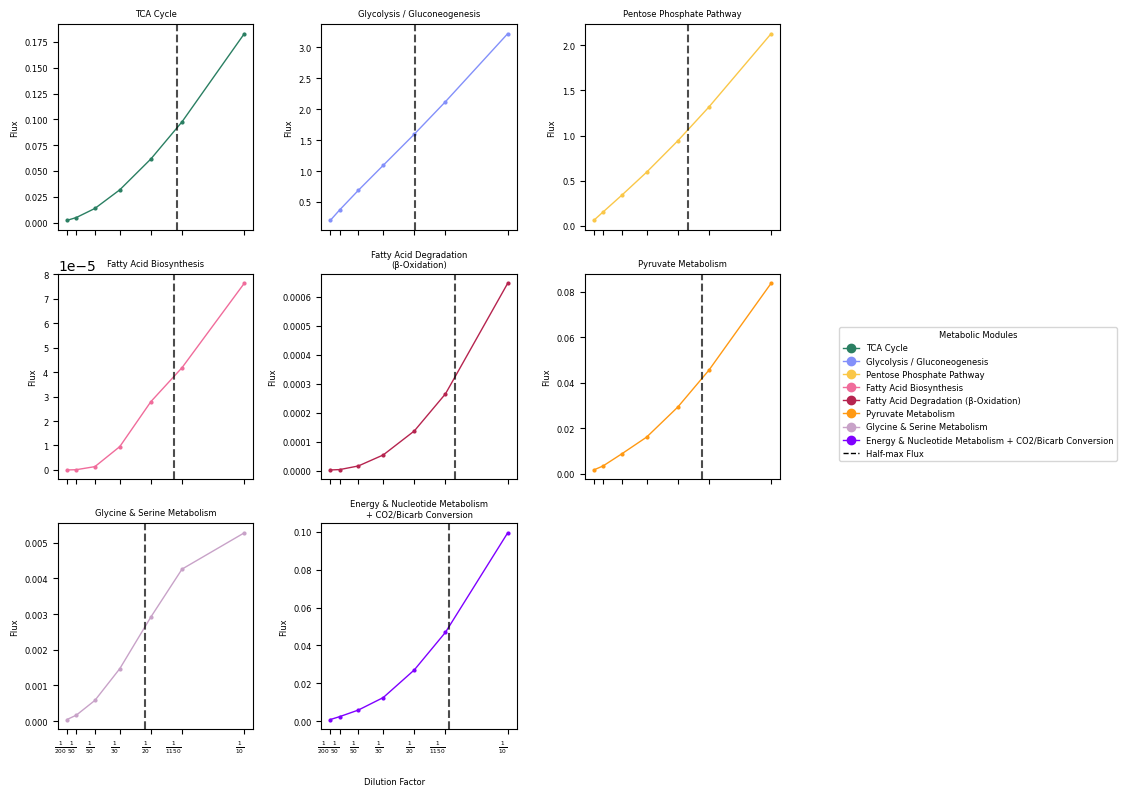

In [ ]:
# Define dilution factors and their labels
d_factors = np.array([1/200, 1/100, 1/50, 1/30, 1/20, 1/15, 1/10])
d_labels = [r"$\frac{1}{200}$", r"$\frac{1}{100}$",
            r"$\frac{1}{50}$", r"$\frac{1}{30}$",
            r"$\frac{1}{20}$", r"$\frac{1}{15}$",
            r"$\frac{1}{10}$"]

# Use the same module colors from the stacked area plot
num_modules = len(module_fluxes)
module_color_dict = {
        "TCA Cycle": "#2A7F62",
        "Glycolysis / Gluconeogenesis": "#8390FA",
        "Pentose Phosphate Pathway": "#FAC748",
        "Fatty Acid Biosynthesis": "#F06C9B",
        "Fatty Acid Degradation (β-Oxidation)": "#B6244F",
        "Pyruvate Metabolism": "#FF9913",
        "Glycine & Serine Metabolism": "#C8A2C8",
        "Energy & Nucleotide Metabolism + CO2/Bicarb Conversion": "#7F00FF",
    }
colors = [module_color_dict[m] for m in module_fluxes]

# Create subplots in a 3-row × 2-column layout
ncols = 2
nrows = int(np.ceil(num_modules / ncols))
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(8, 8), sharex=True)

axes = axes.flatten()

for idx, (ax, (module, color)) in enumerate(zip(axes, zip(module_fluxes.keys(), colors))):
    module_flux = []

    for i in range(len(d_factors)):
        total_flux = sum(dil_tot_flux[i][reaction_ids.index(reaction)]
                         for reaction in pathway_dict[module] if reaction in reaction_ids)
        module_flux.append(total_flux)

    module_flux = np.array(module_flux)

    max_flux = np.max(module_flux)
    half_max_flux = max_flux / 2
    above_half_max = np.where(module_flux >= half_max_flux)[0]

    if len(above_half_max) > 0 and above_half_max[0] > 0:
        idx1, idx2 = above_half_max[0] - 1, above_half_max[0]
        d1, d2 = d_factors[idx1], d_factors[idx2]
        f1, f2 = module_flux[idx1], module_flux[idx2]
        half_max_dilution = np.interp(half_max_flux, [f1, f2], [d1, d2])
    else:
        half_max_dilution = d_factors[0]

    ax.plot(d_factors, module_flux, linestyle='-', color=color, marker='o', markersize=2, label=module, linewidth=1)
    ax.axvline(x=half_max_dilution, linestyle='--', color='black', alpha=0.7)

    wrapped_title = "\n".join(textwrap.wrap(module, width=30))  # Adjust width as needed
    ax.set_title(wrapped_title, fontsize=6, wrap=True)

    ax.set_ylabel("Flux", fontsize=6)
    ax.tick_params(labelsize=6)
    # Define which labels to show (None means skip that label but keep the tick)
    filtered_labels = [r"$\frac{1}{200}$", r"$\frac{1}{50}$",
            r"$\frac{1}{50}$", r"$\frac{1}{30}$", 
            r"$\frac{1}{20}$", r"$\frac{1}{1150}$", 
            r"$\frac{1}{10}$"]

    ax.set_xticks(d_factors)
    ax.set_xticklabels(filtered_labels, rotation=0, ha='right', fontsize=6)

    ax.yaxis.set_tick_params(labelsize=6)

# Turn off unused axes
for i in range(num_modules, len(axes)):
    fig.delaxes(axes[i])

# Custom legend
module_handles = [plt.Line2D([0], [0], color=color, linestyle='-', marker='o', linewidth=1)
                  for color in colors]
half_max_handle = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1, label="Half-max Flux")

fig.legend(module_handles + [half_max_handle],
           list(module_fluxes.keys()) + ["Half-max Flux"],
           title="Metabolic Modules",
           bbox_to_anchor=(1.05, 0.5), loc="center left",
           fontsize=6, title_fontsize=6)

fig.supxlabel("Dilution Factor", fontsize=6)

plt.tight_layout()
plt.savefig(r"Figures\Figure_4B.svg")
plt.show()

## Figure 4C:
### Heatmap: How do reactions/metabolites(?) change relative to dilution or an inhibitor (first introduction)? x-axis is either a reaction or a metabolite; y-axis is a dilution factor or +/- HCT (or a combination?); hue of heatmap corresponds to either total reaction flux or total metabolite production/consumption.

In [ ]:
# Interventions: dilution factors and HCT condition
d_factors = [1/10, 1/50, 1/100, 1/200]
# d_factors = [1/10, 1/10.0001]
intervention_labels = [f"1/{int(1/d)}X" for d in d_factors]
# intervention_labels = ['HCT=1'] + [f'dil={d}' for d in d_factors]

In [ ]:
# Simulation setup
total_time = 4 * 60 * 60  # 4 hours
dt = 60*20
num_steps = total_time // dt
stoich_matrix = rfit.getFullStoichiometryMatrix()

In [ ]:
rids = []
for rxn in rfit.getReactionIds():
    if rxn.startswith('R'):
        rids.append(rxn)

In [ ]:
reaction_labels = []

for r in rids:
    row = model_rxns[model_rxns['Label'] == r]
    keggid = row['Reaction ID'].values[0]

    reaction_labels.append(keggid)

In [ ]:
ordered_labels = {}

for pathway, rids_in_pathway in pathway_dict.items():
    labels_list = []
    for rid in rids_in_pathway:
        if rid in rids:
            idx = rids.index(rid)
            labels_list.append(reaction_labels[idx])
    ordered_labels[pathway] = labels_list

In [ ]:
# Storage for results
heatmap_data = []
intervention_labels = []

time_points = np.arange(0, 4*60*60 + 1, 30*60)  # 10 min intervals for 8 hours
dt = 30 * 60  # 30 minutes in seconds

for d in d_factors:
    # Copy param_values_dict to avoid modifying it globally
    param_values = param_values_dict.copy()

    param_values['v73'] = 0

    # Set parameters in the model
    rfit.model.setGlobalParameterValues(
        [*param_labels_dict.values(), 2, 49, 51, 53],
        [*param_values.values(), d, 0, 0, 0]
    )
    rfit.reset()

    # Simulate and collect rates
    rate_records = []
    for j in range(len(time_points) - 1):
        rfit.simulate(int(time_points[j]), int(time_points[j + 1]))
        rate_records.append(rfit.getReactionRates()[:57])

    rate_records = np.array(rate_records)
    integrated_flux = np.trapz(rate_records, dx=dt, axis=0)

    heatmap_data.append(integrated_flux)

    rfit.resetToOrigin()

    intervention_labels.append(f"{d}X)")

# Build DataFrame
heatmap_df = pd.DataFrame(heatmap_data, columns=rids, index=intervention_labels)

In [ ]:
def symmetric_log_transform(x, lin_thresh=1e-2):
    """
    Apply a symmetric log transform that:
    - Acts linearly near 0 (for values smaller than lin_thresh),
    - Applies log scaling beyond that.
    """
    x = np.asarray(x)
    sign = np.sign(x)
    abs_x = np.abs(x)

    linear_region = abs_x < lin_thresh
    transformed = np.empty_like(x, dtype=float)

    # Linear region: keep the values as-is
    transformed[linear_region] = abs_x[linear_region] / lin_thresh

    # Log region: scale log10 starting from lin_thresh
    transformed[~linear_region] = 1 + np.log10(abs_x[~linear_region] / lin_thresh)

    return sign * transformed

In [ ]:
heatmap_log_signed = heatmap_df.applymap(symmetric_log_transform)

/tmp/ipykernel_42542/3950875419.py:1: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



In [ ]:
# Use rids instead of reaction_labels to preserve uniqueness
flattened_rids = []
module_boundaries = []
for pathway, rids_in_pathway in pathway_dict.items():
    filtered = [rid for rid in rids_in_pathway if rid in rids]
    flattened_rids.extend(filtered)
    module_boundaries.append(len(flattened_rids))  # 1-based index

heatmap_reordered = heatmap_log_signed[flattened_rids]

In [ ]:
# Map from rid to full reaction label
rid_to_label = dict(zip(rids, reaction_labels))
xtick_labels = [rid_to_label[rid] for rid in flattened_rids]

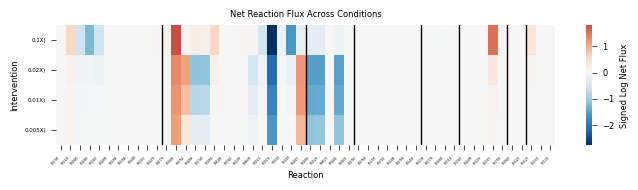

In [ ]:
plt.figure(figsize=(7, 2))
ax = sns.heatmap(
    heatmap_reordered,
    cmap="RdBu_r",
    xticklabels=xtick_labels,
    yticklabels=True,
    center=0,
    cbar_kws={"label": "Signed Log Net Flux"}
)

# Add vertical lines between modules
for boundary in module_boundaries[:-1]:
    ax.axvline(boundary, color='black', linewidth=1)

# Tick and label formatting
ax.tick_params(axis='x', width=0.5)
ax.tick_params(axis='y', width=0.5)
ax.set_ylabel("Intervention", fontsize=6)
ax.set_xlabel("Reaction", fontsize=6)
ax.set_title("Net Reaction Flux Across Conditions", fontsize=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=2)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=4)

# Format colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=6, width=0.5)
cbar.set_label("Signed Log Net Flux", fontsize=6)

plt.tight_layout()
plt.savefig("Figures/Figure_4C.svg")
plt.show()

## Sidebar: clustering parameter sets

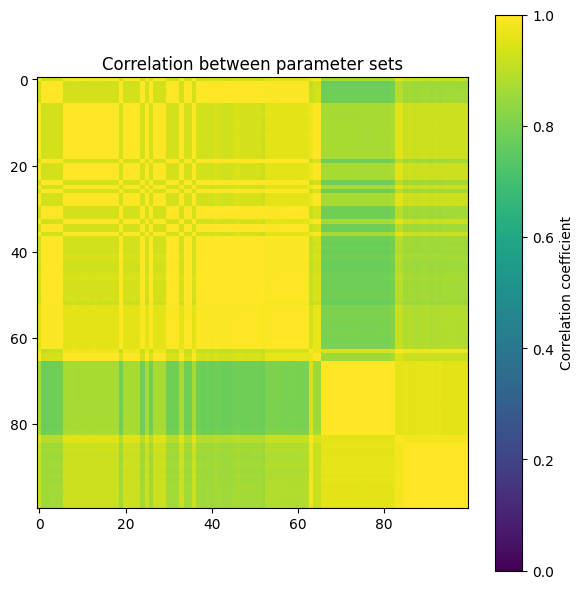

In [ ]:
param_dicts = [entry[2] for entry in trainparams]
df = pd.DataFrame(param_dicts)

corr_matrix = np.corrcoef(df.values)

plt.figure(figsize=(6,6))
plt.imshow(corr_matrix, vmin=0, vmax=1, cmap='viridis')
plt.colorbar(label='Correlation coefficient')
plt.title("Correlation between parameter sets")
plt.tight_layout()
plt.show()

In [ ]:
cluster1 = trainparams[1:6]
cluster2 = trainparams[6:19]
cluster3 = trainparams[20:24]
cluster4 = trainparams[37:63]
cluster5 = trainparams[66:83]
cluster6 = trainparams[85:101]

## Figure 4D:
### Looking towards the sinks of the system

In [ ]:
# Spikes and corresponding parameter IDs
spikes = {"Malate": "v56", "Pyruvate": "v53", "Serine": "v38"}
dilutions = {"10X": 1/10, "200X": 1/200}  # adjust as needed

ids = rfit.getIds()
subset = ids[51:81] + ids[82:95] + ids[97:122] + [ids[124], ids[125]]

# Store results: all_subset_changes[spike_name][dilution_name] = list of lists [time][metabolite]
all_subset_changes = {}
all_tlist = {}

for spike_name, spike_param in spikes.items():
    all_subset_changes[spike_name] = {}
    all_tlist[spike_name] = {}
    
    for d_name, d in dilutions.items():
        subset_changes_d = []
        tlist_d = None
        
        for i in range(len(cluster4)):
            # --- Setup parameter dicts ---
            param_labels_dict = {}
            param_values_dict = {}
            for k, pid in enumerate(rfit.model.getGlobalParameterIds()):
                if pid in cluster4[i][2]:
                    param_values_dict[pid] = cluster4[i][2][pid]
                    param_labels_dict[pid] = k
            param_values = param_values_dict.copy()
            
            # --- Negative control (no spike) ---
            param_values[spike_param] = 0
            rfit.model.setGlobalParameterValues(
                [*param_labels_dict.values(), 2, 49, 50, 51],
                [*param_values.values(), d, 0, 0, 0]
            )
            rfit.reset()
            sim_neg = rfit.simulate(0, 4*60*60)  # 4 hours

            if spike_name == 'Malate':
                # --- Spike-in ---
                param_values[spike_param] = 5 / 1.7 / d  # example spike value
                rfit.model.setGlobalParameterValues(
                    [*param_labels_dict.values(), 2, 49, 50, 51],
                    [*param_values.values(), d, 0, 0, 0]
                )
            else:
                param_values[spike_param] = 5 / 0.001 / d  # example spike value
                rfit.model.setGlobalParameterValues(
                    [*param_labels_dict.values(), 2, 49, 50, 51],
                    [*param_values.values(), d, 0, 0, 0]
                )
            rfit.reset()
            sim_spike = rfit.simulate(0, 4*60*60)
            
            # --- Compute change vs negative control ---
            change = sim_spike - sim_neg
            # Subset only metabolites of interest
            subset_changes = []
            for i in range(len(change)):
                subset_changes.append(list(change[i][51:81]) + list(change[i][82:95]) + list(change[i][97:122]) + list([change[i][124], change[i][125]]))
                
            subset_changes_d.append(list(subset_changes))
            
            # Save tlist (same for all simulations)
            if tlist_d is None:
                tlist_d = list(sim_spike['time'])
        
        all_subset_changes[spike_name][d_name] = subset_changes_d
        all_tlist[spike_name][d_name] = tlist_d


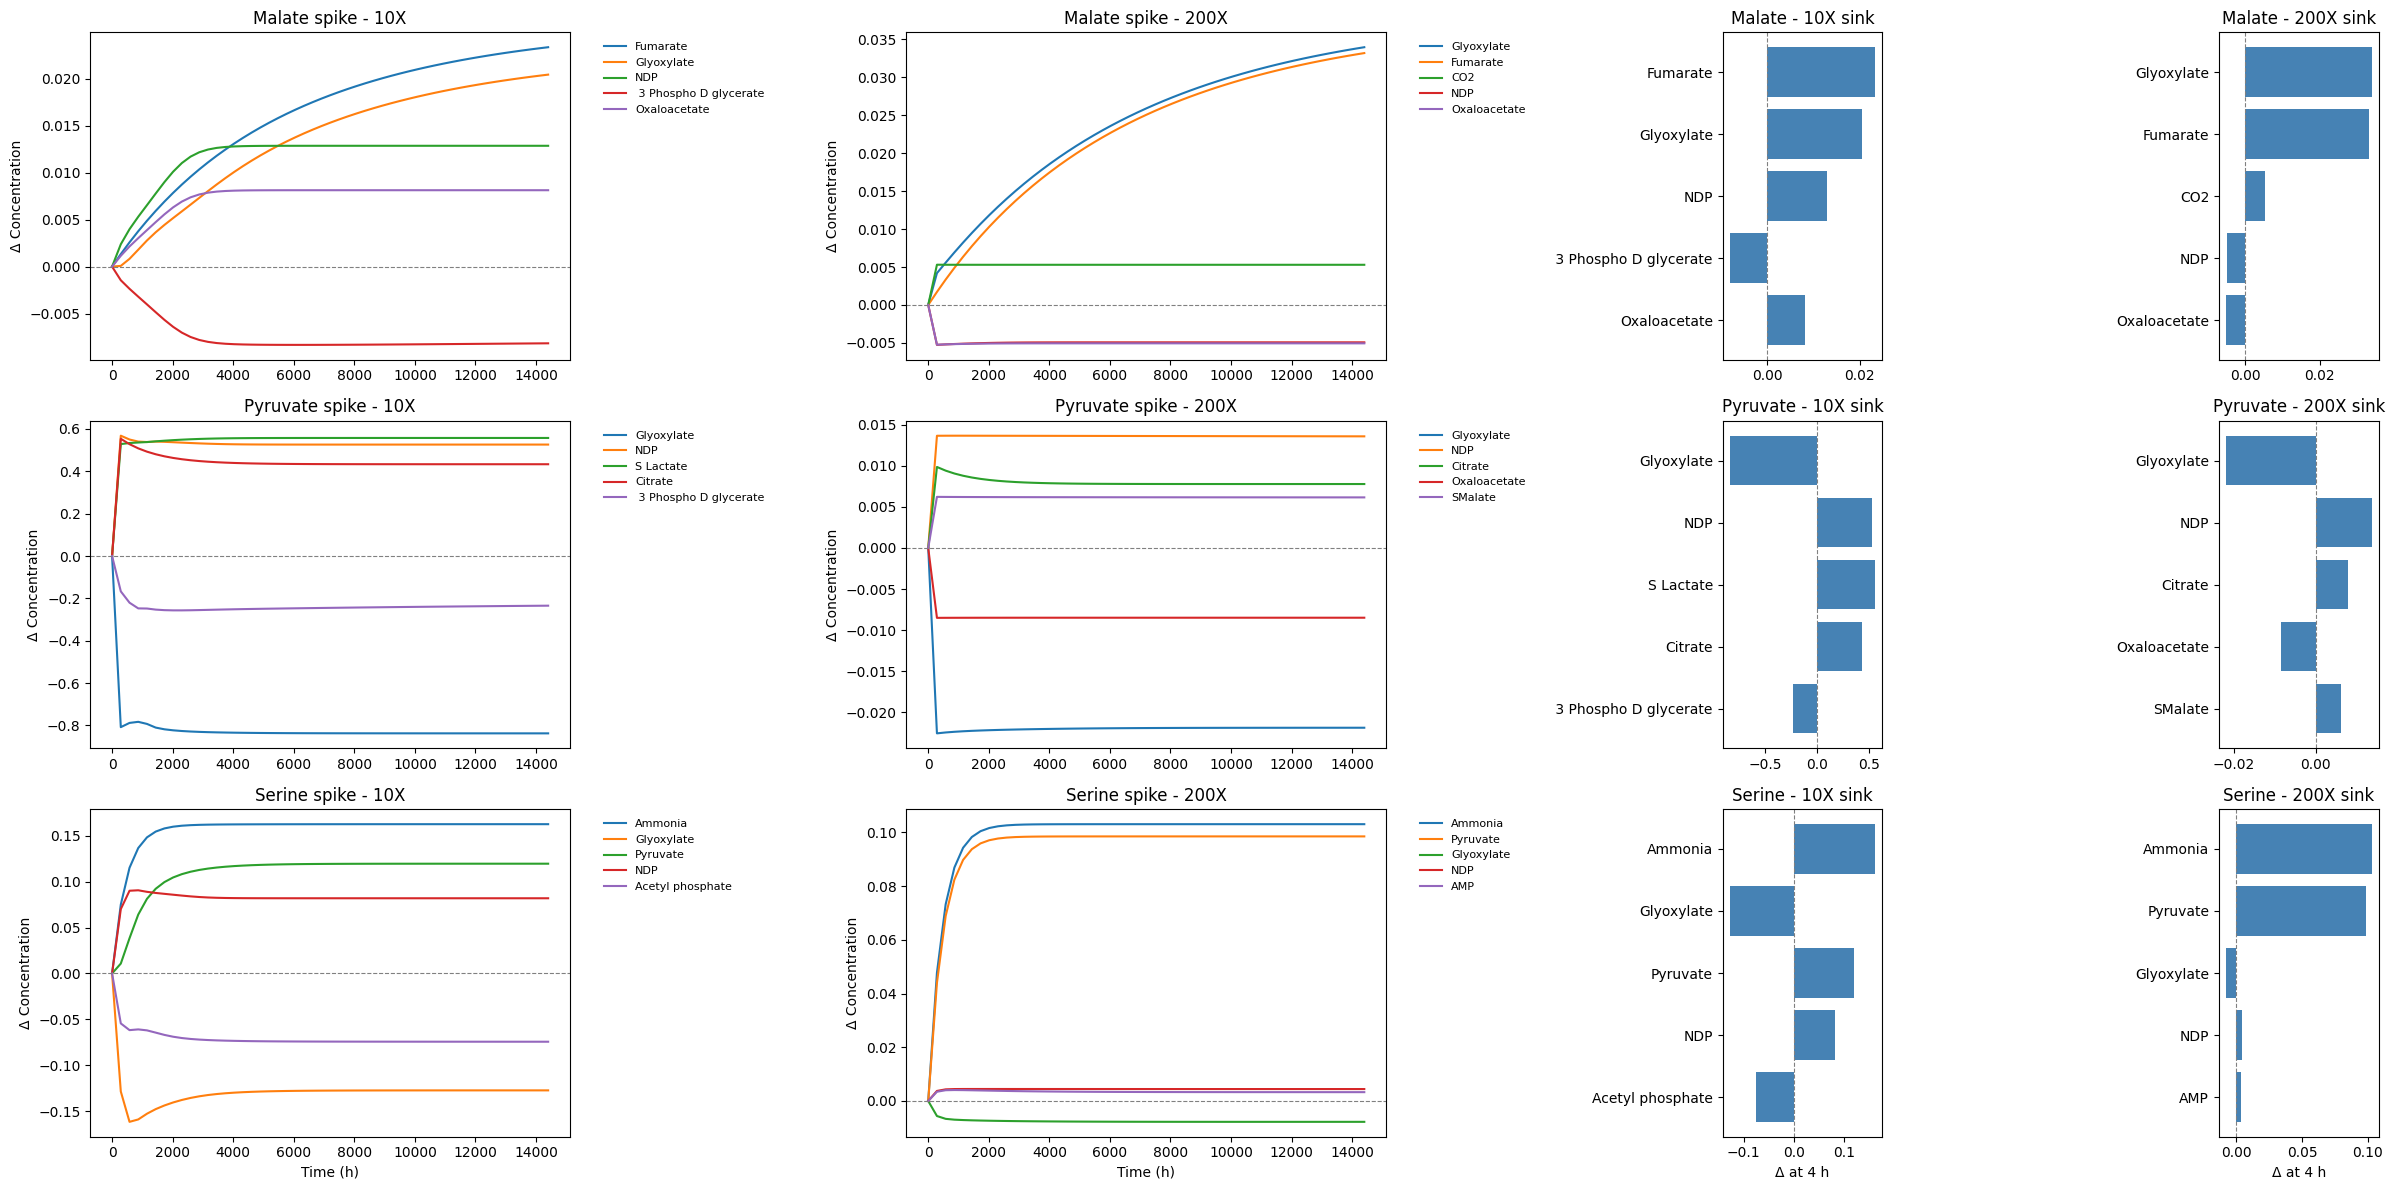

In [ ]:
# Example: metabolites and dilution factors
metabolite_spikes = ["Malate", "Pyruvate", "Serine"]
dilutions = ['10X', '200X']  # 10X, 200X

n_top = 5
threshold_label = 0.001
threshold_hide = 1

fig, axs = plt.subplots(len(metabolite_spikes), 4, figsize=(24, 12),
                        gridspec_kw={'width_ratios':[3,3,1,1]})

for row, spike in enumerate(metabolite_spikes):
    for col, d in enumerate(dilutions):
        # subset_changes for this metabolite + dilution
        changes = all_subset_changes[spike][d][0]  # should be list of lists [time][metabolite]
        tlist = all_tlist[spike][d]

        # Compute max absolute change for ranking
        max_changes = [np.max(np.abs([changes[j][i] for j in range(len(tlist))])) 
                       for i in range(len(subset))]
        top_indices = np.argsort(max_changes)[-n_top-1:-1][::-1]

        # Line plot (left two columns)
        ax_line = axs[row, col]
        for i in top_indices:
            y = np.array([changes[j][i] for j in range(len(tlist))])
            if np.any(np.abs(y) > threshold_hide):
                continue
            label = subset[i-1].replace("_", " ") if np.any(np.abs(y) > threshold_label) else "_nolegend_"
            ax_line.plot(tlist, y, linewidth=1.5, label=label)
        ax_line.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        if row == len(metabolite_spikes)-1:
            ax_line.set_xlabel("Time (h)")
        ax_line.set_ylabel("Δ Concentration")
        ax_line.set_title(f"{spike} spike - {d}")

        # if row == 0:
        ax_line.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

        # Endpoint sink map (right two columns)
        ax_bar = axs[row, col+2]
        endpoint_values = [changes[-1][i] for i in top_indices]
        top_metabolites = [subset[i-1].replace("_"," ") for i in top_indices]
        ax_bar.barh(range(len(top_metabolites)), endpoint_values, color='steelblue')
        ax_bar.axvline(0, color='gray', linewidth=0.8, linestyle='--')
        ax_bar.set_yticks(range(len(top_metabolites)))
        if col == 0:
            ax_bar.set_yticklabels(top_metabolites)
        else:
            ax_bar.set_yticklabels(top_metabolites)
        if row == len(metabolite_spikes)-1:
            ax_bar.set_xlabel("Δ at 4 h")
        ax_bar.invert_yaxis()  # largest on top
        ax_bar.set_title(f"{spike} - {d} sink")

plt.tight_layout()
plt.savefig("Figures/Figure_4D.svg")
plt.show()